In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [57]:
df = pd.read_csv('Scores.csv', sep=';', decimal=',')

print(df.head(10))

   Unnamed: 0 student_id  gender parental.level.of.education   subject  score
0           1     id_001  female                 high school      math   23.0
1           2     id_001  female                 high school  language   40.0
2           3     id_002  female                 high school      math   68.0
3           4     id_002  female                 high school  language   80.5
4           5     id_003    male                 high school      math   82.0
5           6     id_003    male                 high school  language   81.0
6           7     id_004  female                 high school      math   58.0
7           8     id_004  female                 high school  language   60.5
8           9     id_005  female                 high school      math   60.0
9          10     id_005  female                 high school  language   69.0


In [58]:
print(df['parental.level.of.education'].unique())
# Print the unique categories AND how many times they appear
print(df['parental.level.of.education'].value_counts())

['high school' "associate's degree" "bachelor's degree" "master's degree"]
parental.level.of.education
associate's degree    354
high school           312
bachelor's degree     188
master's degree       118
Name: count, dtype: int64


In [59]:
print(df.tail(10))

     Unnamed: 0 student_id  gender parental.level.of.education   subject  \
962         963     id_482  female             master's degree      math   
963         964     id_482  female             master's degree  language   
964         965     id_483    male             master's degree      math   
965         966     id_483    male             master's degree  language   
966         967     id_484  female             master's degree      math   
967         968     id_484  female             master's degree  language   
968         969     id_485  female             master's degree      math   
969         970     id_485  female             master's degree  language   
970         971     id_486  female             master's degree      math   
971         972     id_486  female             master's degree  language   

     score  
962   73.0  
963   76.0  
964   72.0  
965   69.0  
966   78.0  
967   93.5  
968   92.0  
969  100.0  
970   88.0  
971   97.0  


In [60]:
print(df.isnull().sum())

Unnamed: 0                     0
student_id                     0
gender                         0
parental.level.of.education    0
subject                        0
score                          0
dtype: int64


In [61]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 972 entries, 0 to 971
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   972 non-null    int64  
 1   student_id                   972 non-null    object 
 2   gender                       972 non-null    object 
 3   parental.level.of.education  972 non-null    object 
 4   subject                      972 non-null    object 
 5   score                        972 non-null    float64
dtypes: float64(1), int64(1), object(4)
memory usage: 45.7+ KB
None


In [62]:
print(df.describe())

       Unnamed: 0       score
count  972.000000  972.000000
mean   486.500000   67.690844
std    280.736531   14.804105
min      1.000000   19.500000
25%    243.750000   57.000000
50%    486.500000   68.000000
75%    729.250000   78.000000
max    972.000000  100.000000


In [63]:
df_pivot = df.pivot(index=['student_id', 'gender', 'parental.level.of.education'], columns='subject', values='score').reset_index()
print(df_pivot.head(10))

subject student_id  gender parental.level.of.education  language  math
0           id_001  female                 high school      40.0  23.0
1           id_002  female                 high school      80.5  68.0
2           id_003    male                 high school      81.0  82.0
3           id_004  female                 high school      60.5  58.0
4           id_005  female                 high school      69.0  60.0
5           id_006    male                 high school      62.5  79.0
6           id_007  female                 high school      83.0  81.0
7           id_008  female                 high school      40.5  34.0
8           id_009    male                 high school      75.5  84.0
9           id_010  female                 high school      73.0  67.0


In [64]:
# Print the unique categories AND how many times they appear
print(df_pivot['parental.level.of.education'].value_counts())

parental.level.of.education
associate's degree    177
high school           156
bachelor's degree      94
master's degree        59
Name: count, dtype: int64


In [65]:
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [66]:
df = pd.read_csv('Scores.csv', delimiter=';')
df['score'] = df['score'].str.replace(',', '.').astype(float)

In [67]:
# Pivot data into 'Wide Format' so each student has one row with Math and Language scores
df_wide = df.pivot(index=['student_id', 'gender', 'parental.level.of.education'], 
                   columns='subject', 
                   values='score').reset_index()

In [68]:
# ==============================================================================
# 2. DESCRIPTIVE STATISTICS
# ==============================================================================
print(" DESCRIPTIVE STATISTICS ")
print("\nMean Scores by Gender:")
print(df_wide.groupby('gender')[['math', 'language']].mean().round(2))

print("\nMean Scores by Parental Education:")
print(df_wide.groupby('parental.level.of.education')[['math', 'language']].mean().round(2))

 DESCRIPTIVE STATISTICS 

Mean Scores by Gender:
subject   math  language
gender                  
female   63.86     73.00
male     68.95     64.93

Mean Scores by Parental Education:
subject                       math  language
parental.level.of.education                 
associate's degree           67.81     70.02
bachelor's degree            68.44     72.06
high school                  62.24     63.53
master's degree              69.75     75.53


([0, 1, 2, 3],
 [Text(0, 0, 'high school'),
  Text(1, 0, "associate's degree"),
  Text(2, 0, "bachelor's degree"),
  Text(3, 0, "master's degree")])

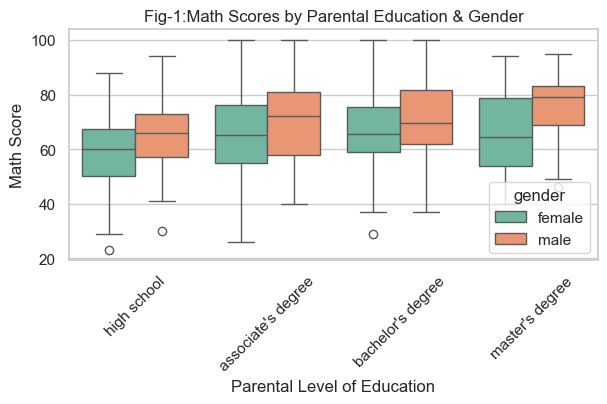

In [97]:
# ==============================================================================
# 3. STATISTICAL GRAPHIC (REQUIRED FOR REPORT)
# ==============================================================================
# We will create a side-by-side boxplot for both Math and Language
plt.figure(figsize=(15, 3))

# Plot 1: Math Scores
plt.subplot(1, 2, 1)
sns.boxplot(x='parental.level.of.education', y='math', hue='gender', data=df_wide, palette='Set2')
plt.title('Fig-1:Math Scores by Parental Education & Gender')
plt.xlabel('Parental Level of Education')
plt.ylabel('Math Score')
plt.xticks(rotation=45)

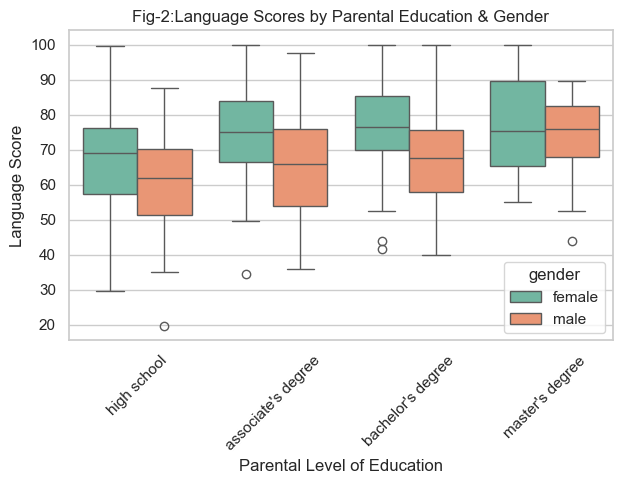

In [98]:
# Plot 2: Language Scores
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
sns.boxplot(x='parental.level.of.education', y='language', hue='gender', data=df_wide, palette='Set2')
plt.title('Fig-2:Language Scores by Parental Education & Gender')
plt.xlabel('Parental Level of Education')
plt.ylabel('Language Score')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('Descriptive_Boxplots.png') # This saves the image so you can put it in your PDF!
plt.show()

In [ ]:
# 4. HYPOTHESIS TESTING 1: T-TESTS (GENDER
print("\nINDEPENDENT T-TESTS: GENDER DIFFERENCES ")
male_math = df_wide[df_wide['gender'] == 'male']['math']
female_math = df_wide[df_wide['gender'] == 'female']['math']
t_math, p_math = stats.ttest_ind(male_math, female_math)
print(f"MATH T-Test     -> t-statistic: {t_math:.4f}, p-value: {p_math:.4f}")

male_lang = df_wide[df_wide['gender'] == 'male']['language']
female_lang = df_wide[df_wide['gender'] == 'female']['language']
t_lang, p_lang = stats.ttest_ind(male_lang, female_lang)
print(f"LANGUAGE T-Test -> t-statistic: {t_lang:.4f}, p-value: {p_lang:.4f}")


INDEPENDENT T-TESTS: GENDER DIFFERENCES 
MATH T-Test     -> t-statistic: 3.7765, p-value: 0.0002
LANGUAGE T-Test -> t-statistic: -6.4087, p-value: 0.0000


In [ ]:
# 5. HYPOTHESIS TESTING 2: ANOVA (PARENTAL EDUCATION)
print("\nONE-WAY ANOVA: PARENTAL EDUCATION")
groups_math = [group['math'].values for name, group in df_wide.groupby('parental.level.of.education')]
f_math, p_anova_math = stats.f_oneway(*groups_math)
print(f"MATH ANOVA     -> F-statistic: {f_math:.4f}, p-value: {p_anova_math:.6f}")

groups_lang = [group['language'].values for name, group in df_wide.groupby('parental.level.of.education')]
f_lang, p_anova_lang = stats.f_oneway(*groups_lang)
print(f"LANGUAGE ANOVA -> F-statistic: {f_lang:.4f}, p-value: {p_anova_lang:.6f}")


ONE-WAY ANOVA: PARENTAL EDUCATION
MATH ANOVA     -> F-statistic: 6.2229, p-value: 0.000375
LANGUAGE ANOVA -> F-statistic: 14.2406, p-value: 0.000000


In [73]:
# ==============================================================================
# 6. HYPOTHESIS TESTING 3: TUKEY HSD POST-HOC
# ==============================================================================
print("\nTUKEY HSD POST-HOC: MATH")
tukey_math = pairwise_tukeyhsd(endog=df_wide['math'], groups=df_wide['parental.level.of.education'], alpha=0.05)
print(tukey_math)

print("\nTUKEY HSD POST-HOC: LANGUAGE")
tukey_lang = pairwise_tukeyhsd(endog=df_wide['language'], groups=df_wide['parental.level.of.education'], alpha=0.05)
print(tukey_lang)


TUKEY HSD POST-HOC: MATH
            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------------
associate's degree bachelor's degree   0.6226 0.9877  -4.2525  5.4977  False
associate's degree       high school    -5.57 0.0037  -9.7649 -1.3751   True
associate's degree   master's degree   1.9322 0.8217  -3.8102  7.6746  False
 bachelor's degree       high school  -6.1926 0.0079 -11.1802  -1.205   True
 bachelor's degree   master's degree   1.3096 0.9512   -5.035  7.6542  False
       high school   master's degree   7.5022 0.0055   1.6639 13.3404   True
----------------------------------------------------------------------------

TUKEY HSD POST-HOC: LANGUAGE
            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
--------------------